In [2]:
import requests

def test_crossref():

    url = "https://api.crossref.org/works"

    params = {

        "query": "artificial intelligence",

        "rows": 1,

        "mailto": "vejodin374@pmdeal.com"

    }

    headers = {"User-Agent": "AcademicTrendsProject/1.0 (mailto:your@email.com)"}

    r = requests.get(url, params=params, headers=headers)

    data = r.json()

    print("CrossRef status:", data["status"])

    print("Total results available:", data["message"]["total-results"])

    print("Sample title:", data["message"]["items"][0].get("title", ["N/A"])[0])

test_crossref()



CrossRef status: ok
Total results available: 1282664
Sample title: Defining Artificial Intelligence


In [3]:
import requests

FIELDS = {

    "Artificial Intelligence": "artificial intelligence",

    "Climate Science": "climate change",

    "Bioinformatics": "bioinformatics",

    "Renewable Energy": "renewable energy",

    "Neuroscience": "neuroscience"

}

MAILTO = "vejodin374@pmdeal.com"

headers = {"User-Agent": f"AcademicTrendsProject/1.0 (mailto:{MAILTO})"}

print("Checking coverage for each field...\n")

for field_name, query in FIELDS.items():

    url = "https://api.crossref.org/works"

    params = {

        "query": query,

        "rows": 1,

        "filter": "from-pub-date:2015,until-pub-date:2025",

        "mailto": MAILTO

    }

    r = requests.get(url, params=params, headers=headers)

    data = r.json()

    total = data["message"]["total-results"]

    print(f"  {field_name:30s} → {total:,} papers")



Checking coverage for each field...

  Artificial Intelligence        → 845,163 papers
  Climate Science                → 787,308 papers
  Bioinformatics                 → 106,754 papers
  Renewable Energy               → 1,750,142 papers
  Neuroscience                   → 263,358 papers


In [4]:
import requests

import pandas as pd

import time

FIELDS = {

    "Artificial Intelligence": "artificial intelligence",

    "Climate Science": "climate change",

    "Bioinformatics": "bioinformatics",

    "Renewable Energy": "renewable energy",

    "Neuroscience": "neuroscience"

}

MAILTO = "vejodin374@pmdeal.com"

YEARS = list(range(2015, 2026))

ROWS_PER_YEAR = 100

headers = {"User-Agent": f"AcademicTrendsProject/1.0 (mailto:{MAILTO})"}

all_records = []

for field_name, query in FIELDS.items():

    print(f"\nFetching: {field_name}")

    for year in YEARS:

        params = {

            "query": query,

            "rows": ROWS_PER_YEAR,

            "filter": f"from-pub-date:{year}-01-01,until-pub-date:{year}-12-31",

            "select": "title,abstract,published,is-referenced-by-count",

            "mailto": MAILTO

        }

        try:

            r = requests.get("https://api.crossref.org/works", params=params, headers=headers)

            items = r.json()["message"]["items"]

            for item in items:

                all_records.append({

                    "field": field_name,

                    "year": year,

                    "title": " ".join(item.get("title", [""])),

                    "abstract": item.get("abstract", ""),

                    "citations": item.get("is-referenced-by-count", 0)

                })

            print(f"  {year}: {len(items)} papers fetched")

        except Exception as e:

            print(f"  {year}: ERROR — {e}")

        time.sleep(0.5)  # be polite to the API

df_raw = pd.DataFrame(all_records)

print(f"\nTotal records collected: {len(df_raw)}")

print(df_raw.head())




Fetching: Artificial Intelligence
  2015: 100 papers fetched
  2016: 100 papers fetched
  2017: 100 papers fetched
  2018: 100 papers fetched
  2019: 100 papers fetched
  2020: 100 papers fetched
  2021: 100 papers fetched
  2022: 100 papers fetched
  2023: 100 papers fetched
  2024: 100 papers fetched
  2025: 100 papers fetched

Fetching: Climate Science
  2015: 100 papers fetched
  2016: 100 papers fetched
  2017: 100 papers fetched
  2018: 100 papers fetched
  2019: 100 papers fetched
  2020: 100 papers fetched
  2021: 100 papers fetched
  2022: 100 papers fetched
  2023: 100 papers fetched
  2024: 100 papers fetched
  2025: 100 papers fetched

Fetching: Bioinformatics
  2015: 100 papers fetched
  2016: 100 papers fetched
  2017: 100 papers fetched
  2018: 100 papers fetched
  2019: 100 papers fetched
  2020: 100 papers fetched
  2021: 100 papers fetched
  2022: 100 papers fetched
  2023: 100 papers fetched
  2024: 100 papers fetched
  2025: 100 papers fetched

Fetching: Renewable 

In [5]:
df_raw.to_csv("raw_publications.csv", index=False)
print("Saved to raw_publications.csv")

Saved to raw_publications.csv


In [6]:
import pandas as pd

df_raw = pd.read_csv("raw_publications.csv")
print("Raw shape:", df_raw.shape)
print("\nMissing values:\n", df_raw.isnull().sum())
print("\nSample titles:")
print(df_raw["title"].value_counts().head(10))

Raw shape: (5500, 5)

Missing values:
 field           0
year            0
title         380
abstract     4328
citations       0
dtype: int64

Sample titles:
title
Editorial Board                          895
PRELIM II(EDI BOARD)                     104
C4 - CONTENTS                             79
Issue Information                         40
Contents                                  34
EUBCE                                     34
OUP accepted manuscript                   31
IFC - Editorial Board etc.                28
EDB (cont'd) and Standard text            26
Designing solutions to climate change     25
Name: count, dtype: int64


LOADIND AND INSPECTING

In [7]:
import pandas as pd
df_raw = pd.read_csv("raw_publications.csv")
print("Raw shape:", df_raw.shape)
print("\nMissing values:\n", df_raw.isnull().sum())
print("\nSample titles:")
print(df_raw["title"].value_counts().head(10))

Raw shape: (5500, 5)

Missing values:
 field           0
year            0
title         380
abstract     4328
citations       0
dtype: int64

Sample titles:
title
Editorial Board                          895
PRELIM II(EDI BOARD)                     104
C4 - CONTENTS                             79
Issue Information                         40
Contents                                  34
EUBCE                                     34
OUP accepted manuscript                   31
IFC - Editorial Board etc.                28
EDB (cont'd) and Standard text            26
Designing solutions to climate change     25
Name: count, dtype: int64


CLEANING THE DATASET

In [8]:

df = df_raw.copy()
junk_titles = [
    "editorial board", "table of contents", "front matter",
    "back matter", "author index", "contents", "masthead",
    "issue information", "copyright", "cover image"
]
def is_junk(title):
    if not isinstance(title, str) or title.strip() == "":
        return True
    return title.strip().lower() in junk_titles
df = df[~df["title"].apply(is_junk)]
df = df[df["title"].str.len() > 10]
df = df.drop_duplicates(subset=["title"])
df["abstract"] = df["abstract"].fillna("")
df = df.reset_index(drop=True)
print("Clean shape:", df.shape)
print(f"Removed {len(df_raw) - len(df)} junk/duplicate records")
print("\nSample clean titles:")
print(df["title"].head(10).tolist())


Clean shape: (3327, 5)
Removed 2173 junk/duplicate records

Sample clean titles:
['iCub: an open platform for research in robotics &amp;amp; artificial intelligence', 'Artificial Intelligence in Medicine AIME 2013', 'Wanted: Collaborative intelligence', 'Information Relations', 'Special Issue on Innovative Artificial Intelligence Solutions for Crisis Management', 'Resource Allocation in Industrial Cloud Computing Using Artificial Intelligence Algorithms', 'Interacting with Artificial Agents', 'Corrigendum', 'Ethical guidelines for a superintelligence', 'Evaluation of Artificial Intelligence Architectures for Optimization of Recombinant Glucoamylase Production in a Microbioreactor']


In [9]:
print("Papers per field:")
print(df.groupby("field")["title"].count().to_string())
print("\nPapers per year (all fields combined):")
print(df.groupby("year")["title"].count().to_string())

Papers per field:
field
Artificial Intelligence    694
Bioinformatics             739
Climate Science            883
Neuroscience               240
Renewable Energy           771

Papers per year (all fields combined):
year
2015    312
2016    322
2017    317
2018    290
2019    266
2020    275
2021    319
2022    307
2023    311
2024    298
2025    310


In [10]:

df.to_csv("clean_publications.csv", index=False)
print("Saved to clean_publications.csv")


Saved to clean_publications.csv


PUBLICATION VOLUME TRENDS

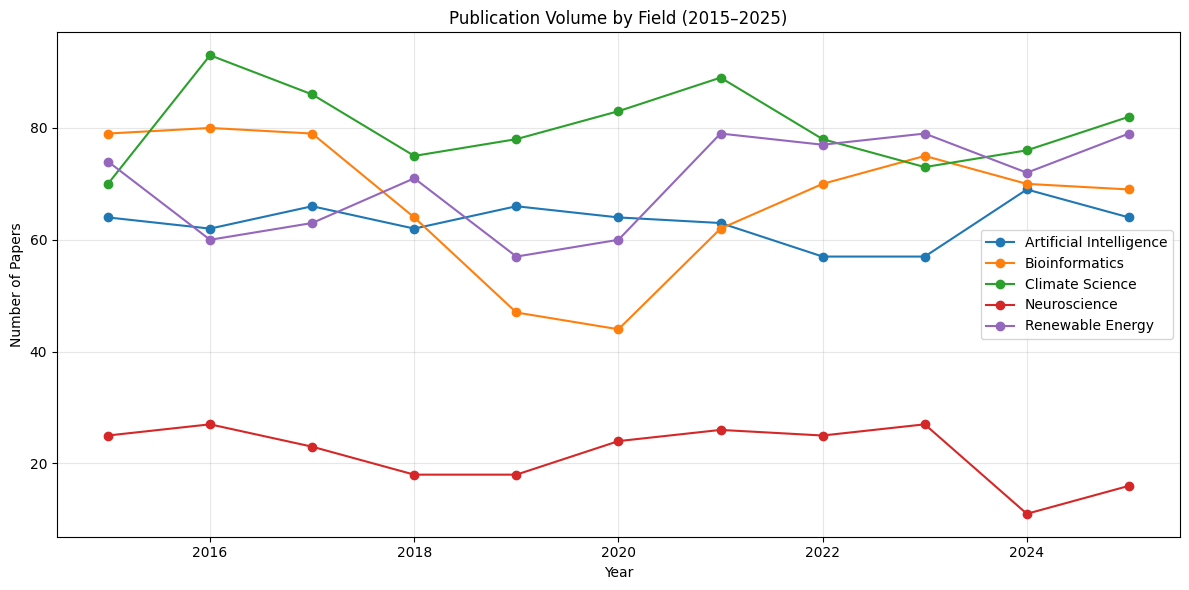

field  Artificial Intelligence  Bioinformatics  Climate Science  Neuroscience  Renewable Energy
year                                                                                           
2015                        64              79               70            25                74
2016                        62              80               93            27                60
2017                        66              79               86            23                63
2018                        62              64               75            18                71
2019                        66              47               78            18                57
2020                        64              44               83            24                60
2021                        63              62               89            26                79
2022                        57              70               78            25                77
2023                        57          

In [11]:
import matplotlib.pyplot as plt

pivot = df.groupby(["year", "field"])["title"].count().unstack()
pivot = pivot.sort_index()

plt.figure(figsize=(12, 6))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], marker='o', label=col)

plt.title("Publication Volume by Field (2015–2025)")
plt.xlabel("Year")
plt.ylabel("Number of Papers")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("volume_trend.png", dpi=150)
plt.show()
print(pivot.to_string())

YEAR OVER YEAR GROWTH RATE

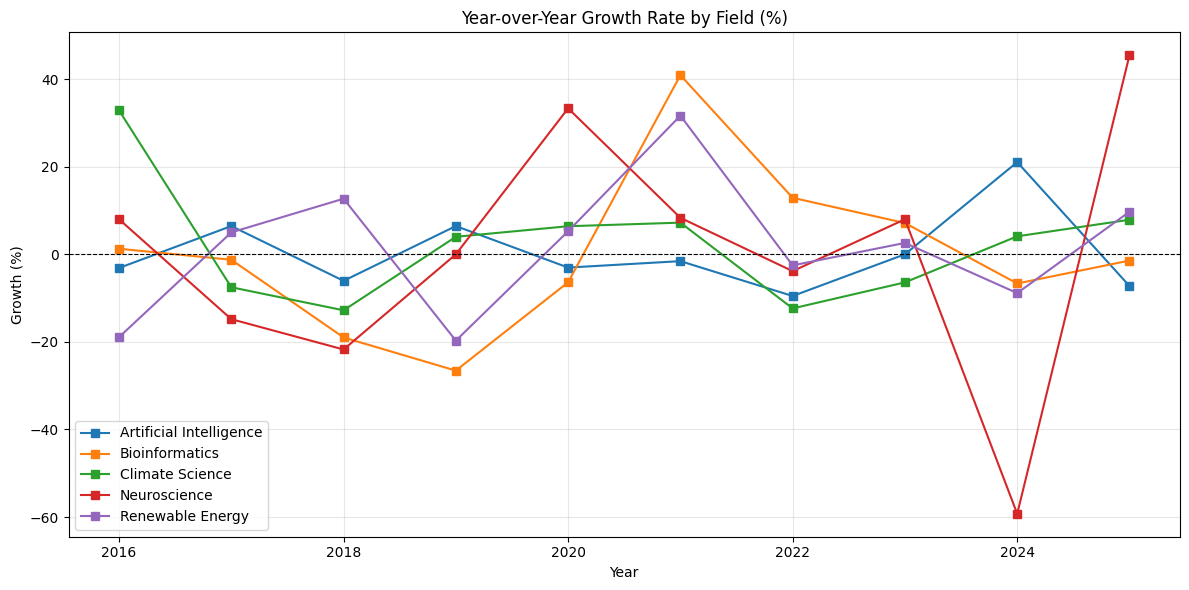

In [12]:

growth = pivot.pct_change() * 100
plt.figure(figsize=(12, 6))
for col in growth.columns:
    plt.plot(growth.index, growth[col], marker='s', label=col)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("Year-over-Year Growth Rate by Field (%)")
plt.xlabel("Year")
plt.ylabel("Growth (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("growth_rate.png", dpi=150)
plt.show()


CITATION ANALYSIS

In [13]:
print("Average citations per field:")
print(df.groupby("field")["citations"].mean().round(2).to_string())

print("\nTop 3 most cited papers per field:")
for field, group in df.groupby("field"):
    top = group.nlargest(3, "citations")[["title", "year", "citations"]]
    print(f"\n--- {field} ---")
    for _, row in top.iterrows():
        print(f"  [{row['year']}] {row['title'][:80]}... ({row['citations']} citations)")

Average citations per field:
field
Artificial Intelligence    19.44
Bioinformatics              6.70
Climate Science            23.52
Neuroscience               10.49
Renewable Energy           59.21

Top 3 most cited papers per field:

--- Artificial Intelligence ---
  [2019] Explanation in artificial intelligence: Insights from the social sciences... (3494 citations)
  [2019] A comprehensive review on automation in agriculture using artificial intelligenc... (516 citations)
  [2023] Smart farming using artificial intelligence: A review... (344 citations)

--- Bioinformatics ---
  [2016] Deep learning in bioinformatics... (514 citations)
  [2018] Snakemake—a scalable bioinformatics workflow engine... (290 citations)
  [2015] An interactive reference framework for modeling a dynamic immune system... (233 citations)

--- Climate Science ---
  [2023] Climate Change 2022 – Impacts, Adaptation and Vulnerability... (4077 citations)
  [2023] Climate Change 2021 – The Physical Science Basis..

LINEAR TRENDS PER FIELD

In [14]:
import numpy as np
from scipy import stats

print("Trend analysis (linear regression slope per field):\n")
trends = {}
for field in pivot.columns:
    y = pivot[field].values
    x = np.arange(len(y))
    slope, intercept, r, p, se = stats.linregress(x, y)
    direction = "EMERGING" if slope > 0 else "DECLINING"
    trends[field] = slope
    print(f"  {field:<25} slope={slope:+.2f}  p={p:.3f}  [{direction}]")

Trend analysis (linear regression slope per field):

  Artificial Intelligence   slope=-0.11  p=0.770  [DECLINING]
  Bioinformatics            slope=-0.68  p=0.588  [DECLINING]
  Climate Science           slope=-0.27  p=0.707  [DECLINING]
  Neuroscience              slope=-0.68  p=0.188  [DECLINING]
  Renewable Energy          slope=+1.41  p=0.082  [EMERGING]


In [ ]:
Visualizing Emerging vs Declining

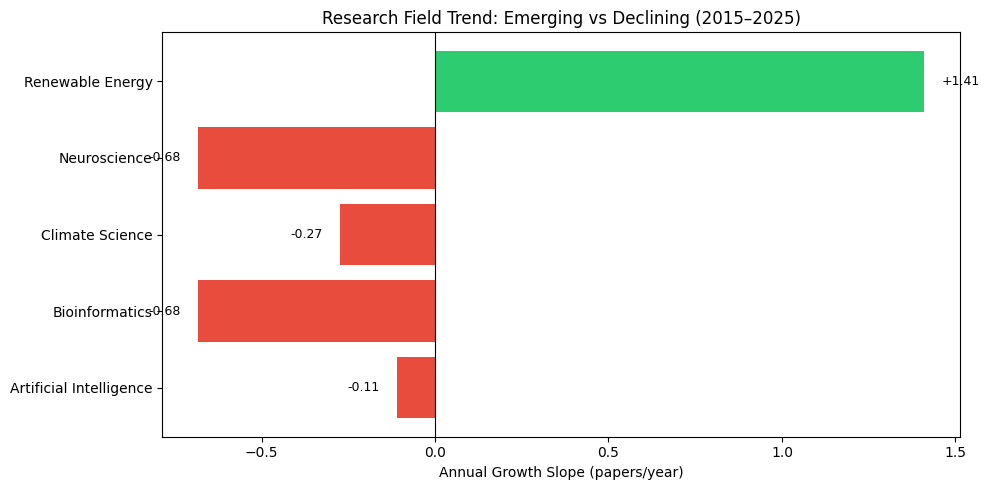

In [15]:
fields = list(trends.keys())
slopes = list(trends.values())
colors = ['#2ecc71' if s > 0 else '#e74c3c' for s in slopes]

plt.figure(figsize=(10, 5))
bars = plt.barh(fields, slopes, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Research Field Trend: Emerging vs Declining (2015–2025)")
plt.xlabel("Annual Growth Slope (papers/year)")
for bar, slope in zip(bars, slopes):
    plt.text(slope + (0.05 if slope >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
             f'{slope:+.2f}', va='center', ha='left' if slope >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig("emerging_declining.png", dpi=150)
plt.show()

3-year moving average (smooth out noise)


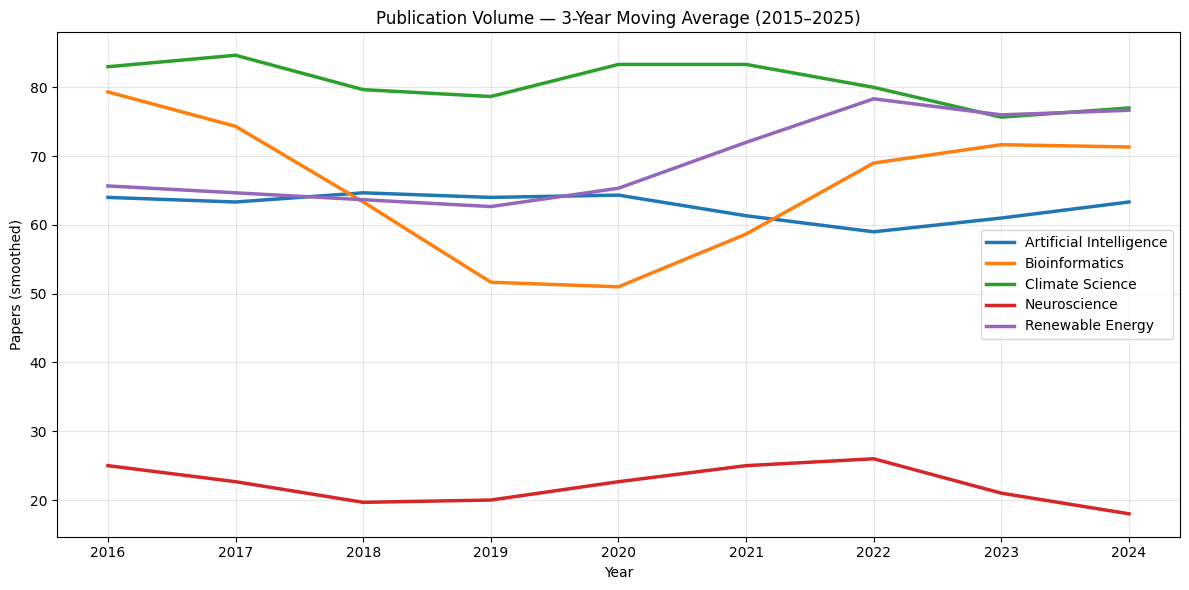

In [16]:
pivot_ma = pivot.rolling(window=3, center=True).mean()

plt.figure(figsize=(12, 6))
for col in pivot_ma.columns:
    plt.plot(pivot_ma.index, pivot_ma[col], linewidth=2.5, label=col)

plt.title("Publication Volume — 3-Year Moving Average (2015–2025)")
plt.xlabel("Year")
plt.ylabel("Papers (smoothed)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("moving_average.png", dpi=150)
plt.show()

Heatmap (field × year)


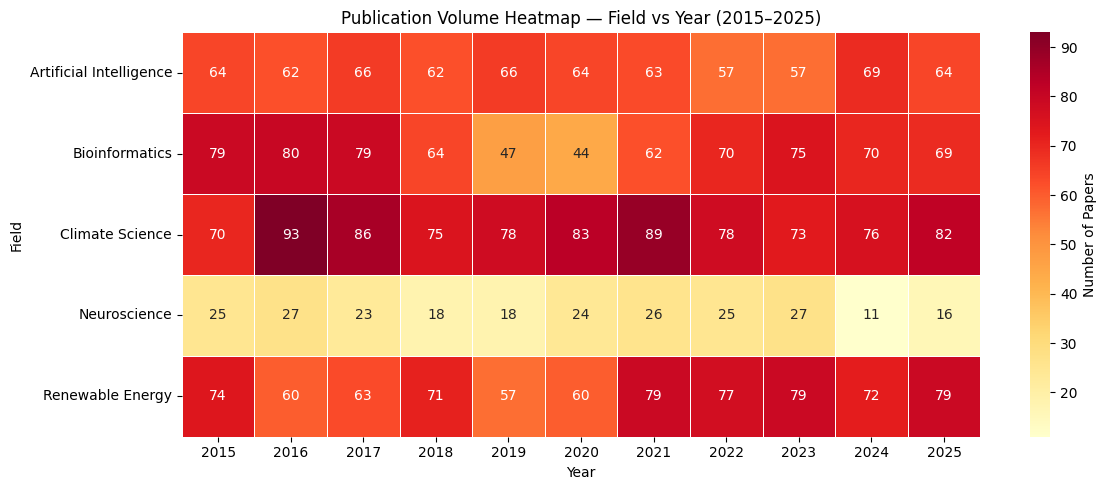

In [17]:
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.heatmap(pivot.T, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Number of Papers'})
plt.title("Publication Volume Heatmap — Field vs Year (2015–2025)")
plt.xlabel("Year")
plt.ylabel("Field")
plt.tight_layout()
plt.savefig("heatmap.png", dpi=150)
plt.show()

Citation comparison bar chart


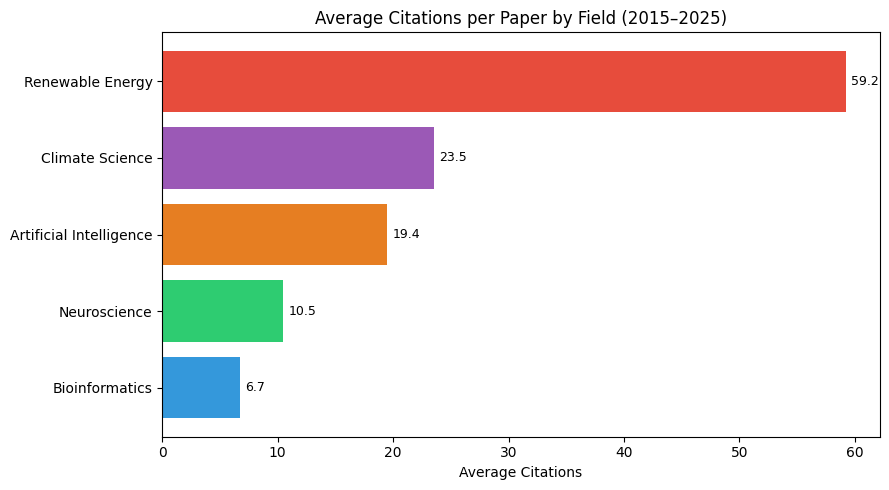

In [18]:

avg_citations = df.groupby("field")["citations"].mean().sort_values(ascending=True)
plt.figure(figsize=(9, 5))
bars = plt.barh(avg_citations.index, avg_citations.values,
                color=['#3498db','#2ecc71','#e67e22','#9b59b6','#e74c3c'])
plt.title("Average Citations per Paper by Field (2015–2025)")
plt.xlabel("Average Citations")
for bar, val in zip(bars, avg_citations.values):
    plt.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig("citations_bar.png", dpi=150)
plt.show()
